# Data-gen pipeline: SMILES → torch_geometric Data

This notebook builds a full `torch_geometric.data.Data` object using the pipeline.
Provide DeepMD models (pot/dipole/polar) or use Psi4 for small molecules.


In [1]:
from pathlib import Path
import sys
import torch

root = Path.cwd()
if (root / "data-gen-pipeline").is_dir():
    pipe_dir = (root / "data-gen-pipeline").resolve()
elif root.name == "data-gen-pipeline":
    pipe_dir = root.resolve()
else:
    raise RuntimeError("Run this notebook from the repo root or data-gen-pipeline/")

sys.path.insert(0, str(pipe_dir))

import pipeline
from deepmd_backend import DeepMDDipoleBackend, DeepMDPolarBackend, DeepMDPotHessianBackend
from psi4_backend import Psi4HessianBackend


In [2]:
smiles = "C"
pot_model = pipe_dir / "checkpoints/dpa2_multi_Domains_Drug.pth"

# Set these if you have DeepMD dipole/polar models.
dipole_model = None
polar_model = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = pipeline.PipelineConfig(
    output_dir=Path("data/gen"),
    device=device,
    dft_atom_cutoff=20,
    graph_k=20,
    graph_clamp_min=0.5,
    graph_clamp_max=100.0,
    pos_step=1e-3,
    allow_missing_polar=True,
    allow_missing_dipole=True,
    psi4_fallback=True,
)


In [3]:
dipole_backend = (
    DeepMDDipoleBackend(device=device, model_path=str(dipole_model))
    if dipole_model
    else None
)
polar_backend = (
    DeepMDPolarBackend(device=device, model_path=str(polar_model))
    if polar_model
    else None
)

hessian_backend = DeepMDPotHessianBackend(
    device=device,
    model_path=str(pot_model),
)

psi4_backend = None
try:
    psi4_backend = Psi4HessianBackend(
        device=torch.device("cpu"),
        method=cfg.psi4_method,
        basis=cfg.psi4_basis,
        charge=cfg.psi4_charge,
        multiplicity=cfg.psi4_multiplicity,
        num_threads=cfg.psi4_threads,
        memory=cfg.psi4_memory,
        scf_type=cfg.psi4_scf_type,
        guess=cfg.psi4_guess,
        quiet=cfg.psi4_quiet,
    )
except Exception as exc:
    print("Psi4 not available:", exc)

if dipole_backend is None and psi4_backend is None and not cfg.allow_missing_dipole:
    raise RuntimeError("Provide a DeepMD dipole model or install Psi4 for small molecules, or set allow_missing_dipole=True.")


To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.


Psi4 not available: psi4 is required for Psi4HessianBackend


In [4]:
item = pipeline.SmilesItem(number=1, smile=smiles)
data = pipeline.build_data_from_smiles(
    item,
    cfg,
    dipole_backend,
    polar_backend,
    hessian_backend,
    psi4_backend,
)
data


Data(edge_index=[2, 20], pos=[5, 3], z=[5], number=1, smile='C', energy=[1, 1], dipole=[1, 3], npacharge=[5], polar=[1, 3, 3], quadrupole=[1, 3, 3], octapole=[1, 3, 3, 3], hyperpolar=[1, 3, 3, 3], Hi=[5, 3, 3], Hij=[20, 3, 3], dedipole=[5, 3, 3], depolar=[5, 3, 6], tran_dipole=[1, 10, 3], tran_energy=[1, 10])

#### should see: 
##### Data(edge_index=[2, 20], pos=[5, 3], number=1, smile='C', z=[5], quadrupole=[1, 3, 3], octapole=[1, 3, 3, 3], npacharge=[5], dipole=[1, 3], polar=[1, 3, 3], hyperpolar=[1, 3, 3, 3], energy=[1, 1], Hij=[20, 3, 3], Hi=[5, 3, 3], dedipole=[5, 3, 3], depolar=[5, 3, 6], tran_dipole=[1, 10, 3], tran_energy=[1, 10])


In [5]:
def shape(val):
    try:
        return tuple(val.shape)
    except Exception:
        return None

for key in data.keys():
    print(f"{key}: {shape(getattr(data, key))}")


tran_energy: (1, 10)
quadrupole: (1, 3, 3)
energy: (1, 1)
octapole: (1, 3, 3, 3)
polar: (1, 3, 3)
pos: (5, 3)
number: None
dipole: (1, 3)
z: (5,)
npacharge: (5,)
dedipole: (5, 3, 3)
depolar: (5, 3, 6)
edge_index: (2, 20)
smile: None
Hij: (20, 3, 3)
Hi: (5, 3, 3)
hyperpolar: (1, 3, 3, 3)
tran_dipole: (1, 10, 3)


### Sanity Testing

In [6]:
dataset=torch.load('../capsule-3259363/data/qm9s.pt', weights_only=False)

In [7]:
len(dataset)

129817

In [8]:
import numpy as np
sample_size = 300  # reduce for quicker debugging
to_check = np.random.choice(len(dataset), size=sample_size, replace=False)


In [9]:
import os
import dataclasses
from mp_validate import run_validation

cfg_mp = dataclasses.replace(cfg, device=torch.device("cpu"), psi4_fallback=False)
max_workers = max(4, os.cpu_count()-2)

result = run_validation(
    dataset_path=Path("../capsule-3259363/data/qm9s.pt"),
    cfg=cfg_mp,
    pot_model=pot_model,
    dipole_model=dipole_model,
    polar_model=polar_model,
    indices=to_check,
    max_workers=max_workers,
    use_psi4=False,
    show_progress=True,
)

print(f"shape errors: {result['shape_error']} ; fraction: {result['shape_fraction']}")
print("shape errors by key:", result.get("shape_error_by_key", {}))
print(result["errors"])
error_dict = result["errors"]


validate:   0%|          | 0/300 [00:00<?, ?it/s]You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The d

shape errors: 0 ; fraction: 0.0
{'tran_energy': [5.280600547790527, 5.36027193069458, 6.180123329162598, 6.222939968109131, 4.379528522491455, 7.059884071350098, 6.5866193771362305, 7.332740783691406, 5.7900261878967285, 6.327369689941406, 7.237863063812256, 6.534243106842041, 6.323505401611328, 6.111987113952637, 7.41058349609375, 5.927791595458984, 6.826138496398926, 7.3055620193481445, 7.218994140625, 6.956789970397949, 6.609803199768066, 6.137497901916504, 6.272752285003662, 5.6450018882751465, 5.6370673179626465, 7.255104064941406, 6.851808071136475, 6.645796775817871, 5.482093811035156, 6.145656585693359, 5.873956203460693, 7.042864799499512, 6.563037872314453, 5.706900596618652, 5.406027793884277, 5.995831489562988, 6.9487786293029785, 7.221426486968994, 6.357272624969482, 6.728102684020996, 7.11051082611084, 6.607351779937744, 7.367137908935547, 7.0246171951293945, 6.352162837982178, 5.843021392822266, 6.07521915435791, 6.833779335021973, 4.323491096496582, 6.32061243057251, 6.

In [10]:
len(error_dict['z'])

300

In [11]:
!pip install -q seaborn

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
error_dict.keys()

dict_keys(['tran_energy', 'z', 'dipole', 'hyperpolar', 'depolar', 'Hij', 'quadrupole', 'tran_dipole', 'pos', 'dedipole', 'energy', 'Hi', 'polar', 'npacharge', 'octapole', 'edge_index'])

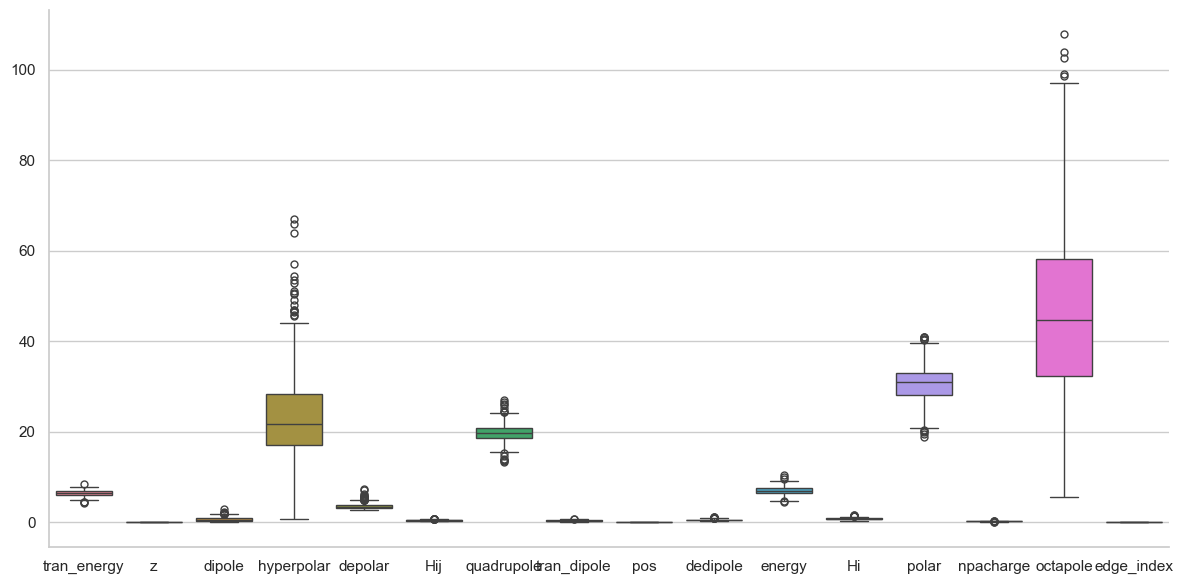

In [14]:
sns.set(style="whitegrid")
sns.catplot(error_dict, kind="box", height=6, aspect=2)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def _to_numpy(x):
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def _is_numeric(arr: np.ndarray) -> bool:
    return np.issubdtype(arr.dtype, np.number)

def _clean_1d(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=np.float64).ravel()
    a = a[np.isfinite(a)]
    return a

def _nice_xlim(x):
    if x.size == 0:
        return None
    lo, hi = np.quantile(x, [0.01, 0.99])
    if np.isclose(lo, hi):
        lo, hi = np.min(x), np.max(x)
    if np.isclose(lo, hi):
        return (lo - 1, hi + 1)
    pad = 0.05 * (hi - lo)
    return (lo - pad, hi + pad)

def _finish_ax(ax, title):
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.25)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

def plot_distributions_seaborn(
    data: dict,
    keys=None,
    bins=50,
    max_cols=4,
    kde=True,
    quantile_clip=True,   # avoids a single outlier nuking the axis
):
    # Global seaborn look
    sns.set_theme(
        style="whitegrid",
        context="talk",
        font_scale=0.9
    )
    sns.set_context("talk", rc={"axes.titlesize": 13, "axes.labelsize": 11})

    if keys is None:
        keys = list(data.keys())

    for k in keys:
        if k not in data:
            continue

        arr = _to_numpy(data[k])

        if arr.size == 0:
            print(f"[skip] {k}: empty")
            continue
        if not _is_numeric(arr):
            print(f"[skip] {k}: non-numeric dtype {arr.dtype}")
            continue

        # ---------- edge_index ----------
        if k == "edge_index":
            a = arr
            if a.ndim == 2 and a.shape[0] == 2:
                fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), constrained_layout=True)
                for i, name in enumerate(["source", "target"]):
                    x = _clean_1d(a[i])
                    sns.histplot(x=x, bins=bins, kde=kde, stat="count",
                                 element="step", fill=True, alpha=0.55, ax=axes[i])
                    _finish_ax(axes[i], f"edge_index[{i}] • {name}")
                    if quantile_clip and x.size > 20:
                        axes[i].set_xlim(_nice_xlim(x))
                fig.suptitle("edge_index", x=0.01, ha="left", fontweight="bold")
                plt.show()
                continue

        # ---------- pos ----------
        if k == "pos":
            a = arr
            if a.ndim == 2 and a.shape[1] in (2, 3):
                d = a.shape[1]
                labels = ["x", "y", "z"][:d]
                fig, axes = plt.subplots(1, d, figsize=(4.2*d + 1.2, 3.6), constrained_layout=True)
                if d == 1:
                    axes = [axes]
                for i, lab in enumerate(labels):
                    x = _clean_1d(a[:, i])
                    sns.histplot(x=x, bins=bins, kde=kde,
                                 element="step", fill=True, alpha=0.55, ax=axes[i])
                    _finish_ax(axes[i], f"pos • {lab}")
                    if quantile_clip and x.size > 20:
                        axes[i].set_xlim(_nice_xlim(x))
                fig.suptitle("pos", x=0.01, ha="left", fontweight="bold")
                plt.show()

                # norm panel
                norm = np.linalg.norm(a.astype(np.float64), axis=1)
                norm = _clean_1d(norm)
                fig, ax = plt.subplots(1, 1, figsize=(8, 3.6), constrained_layout=True)
                sns.histplot(x=norm, bins=bins, kde=kde,
                             element="step", fill=True, alpha=0.55, ax=ax)
                _finish_ax(ax, "pos • norm")
                if quantile_clip and norm.size > 20:
                    ax.set_xlim(_nice_xlim(norm))
                plt.show()
                continue

        # ---------- general ----------
        a = arr

        # If (N, d) with small d, do small multiples
        if a.ndim == 2 and a.shape[1] <= max_cols and a.shape[0] > 1:
            d = a.shape[1]
            fig, axes = plt.subplots(1, d, figsize=(4.2*d + 1.2, 3.6), constrained_layout=True)
            if d == 1:
                axes = [axes]
            for i in range(d):
                x = _clean_1d(a[:, i])
                sns.histplot(x=x, bins=bins, kde=kde,
                             element="step", fill=True, alpha=0.55, ax=axes[i])
                _finish_ax(axes[i], f"{k} • [{i}]")
                if quantile_clip and x.size > 20:
                    axes[i].set_xlim(_nice_xlim(x))
            fig.suptitle(k, x=0.01, ha="left", fontweight="bold")
            plt.show()
            continue

        # Otherwise: single distribution (flatten)
        x = _clean_1d(a)
        if x.size == 0:
            print(f"[skip] {k}: no finite values")
            continue

        fig, ax = plt.subplots(1, 1, figsize=(8, 3.6), constrained_layout=True)
        sns.histplot(
            x=x,
            bins=bins,
            kde=kde,
            stat="count",
            element="step",
            fill=True,
            alpha=0.55,
            ax=ax,
        )
        _finish_ax(ax, k)
        if quantile_clip and x.size > 20:
            ax.set_xlim(_nice_xlim(x))
        plt.show()

In [16]:
keys = [
    "energy", "edge_index", "tran_dipole", "tran_energy", "octapole", "z", "polar",
    "Hi", "dedipole", "dipole", "depolar", "quadrupole", "pos", "hyperpolar",
    "Hij", "npacharge"
]

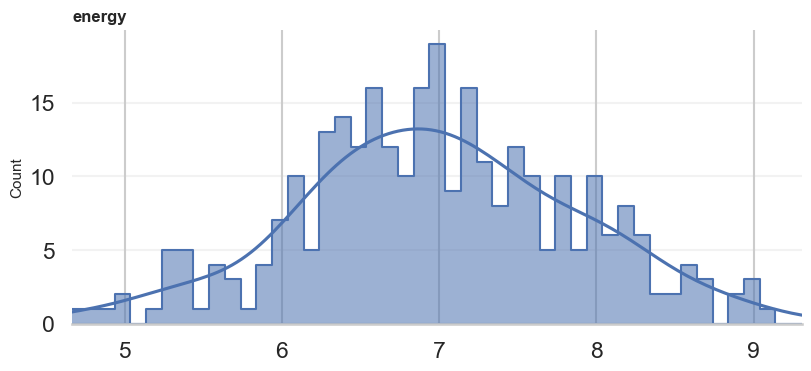

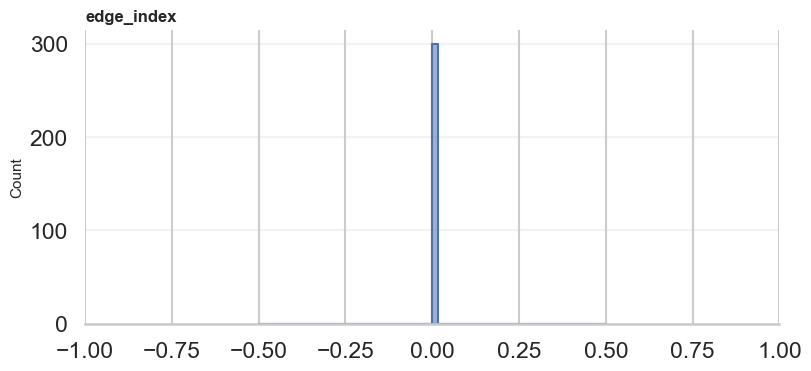

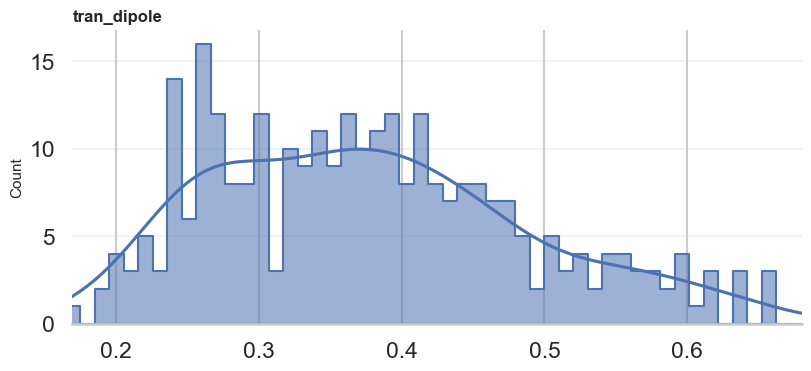

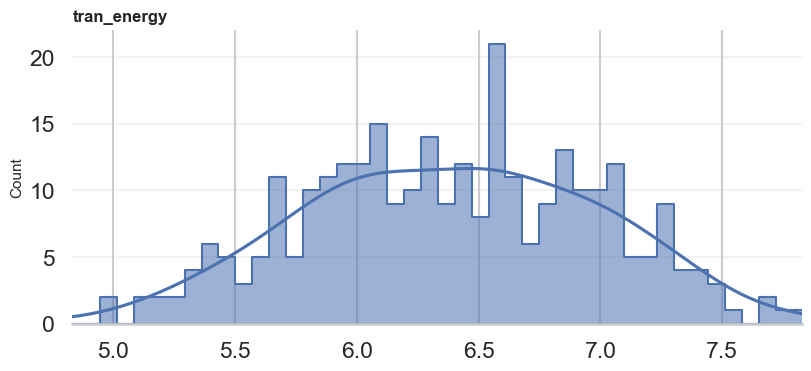

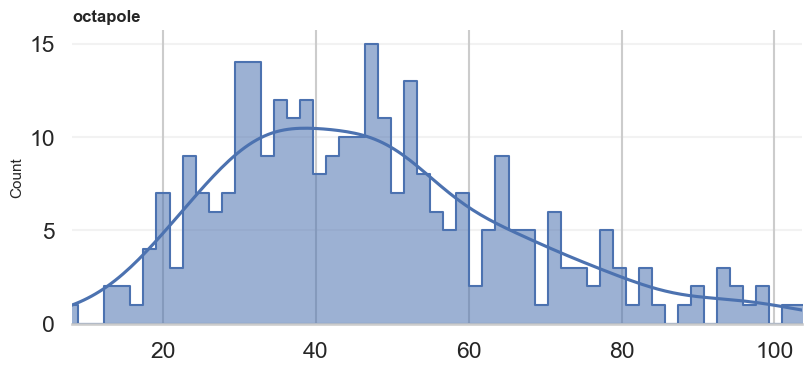

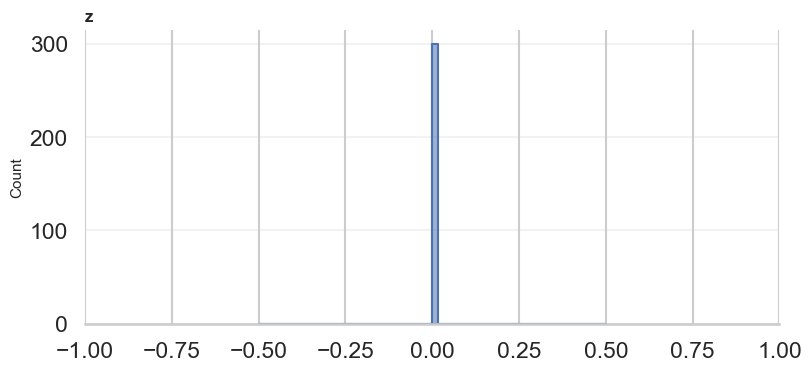

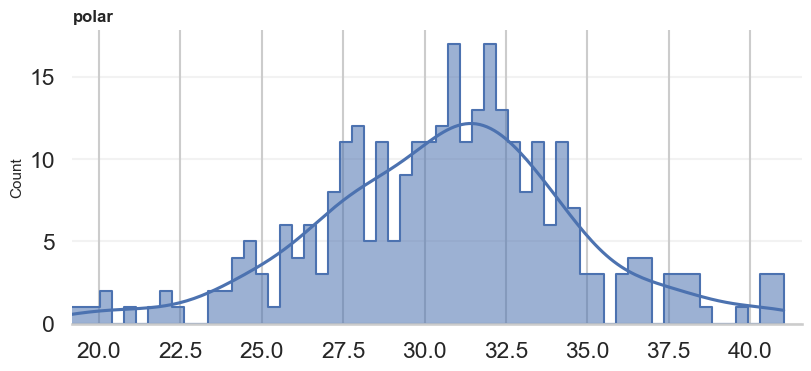

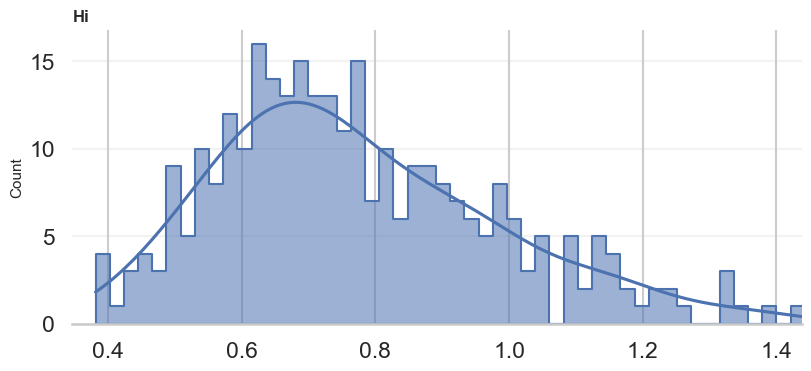

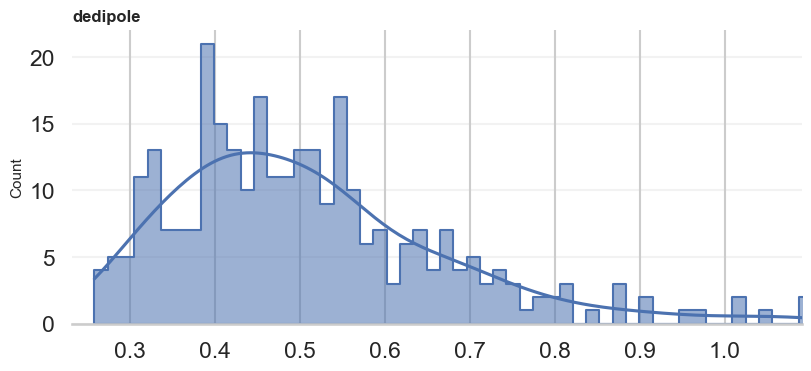

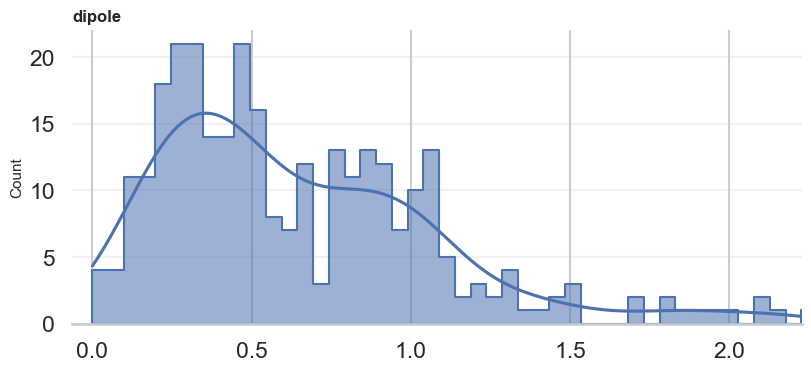

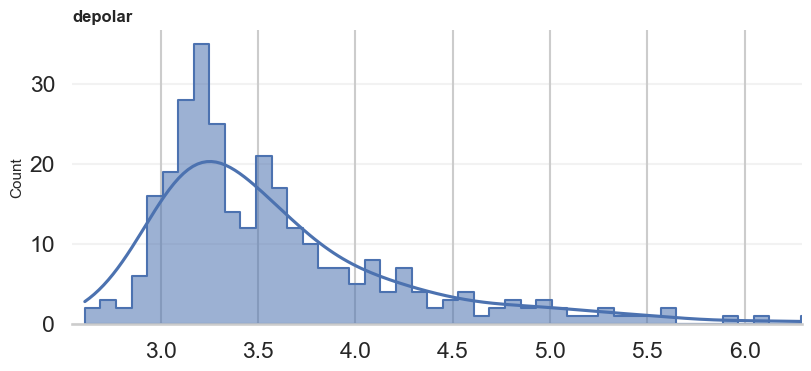

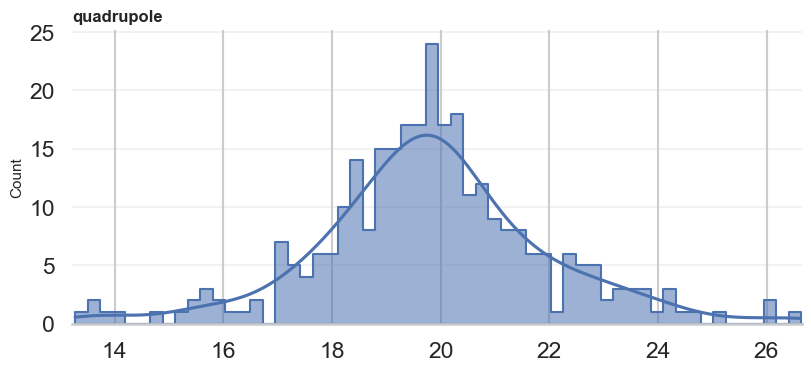

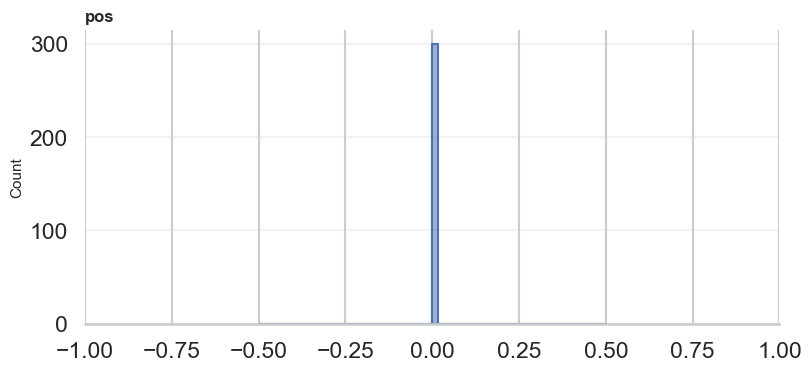

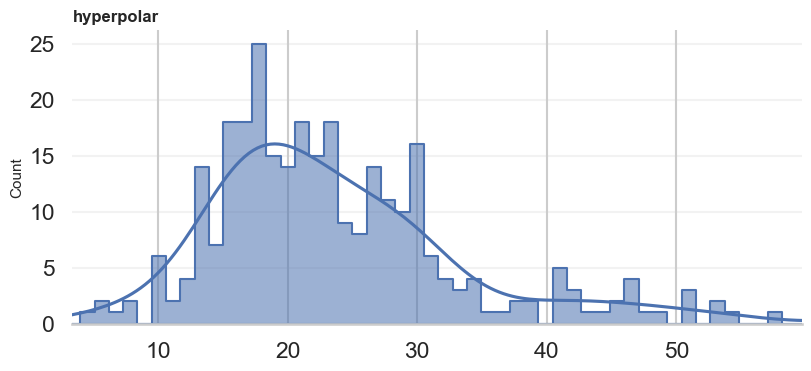

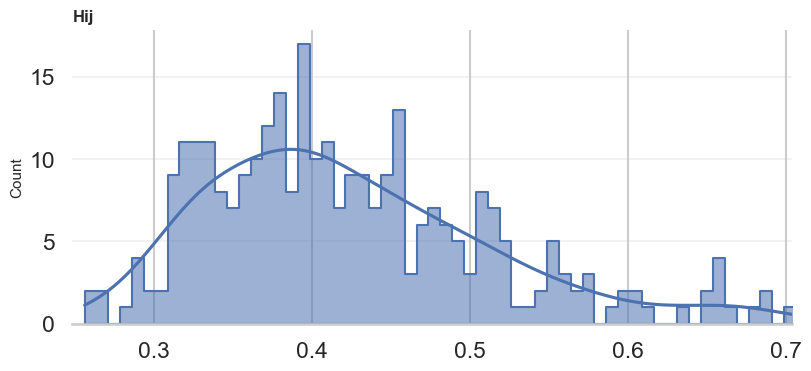

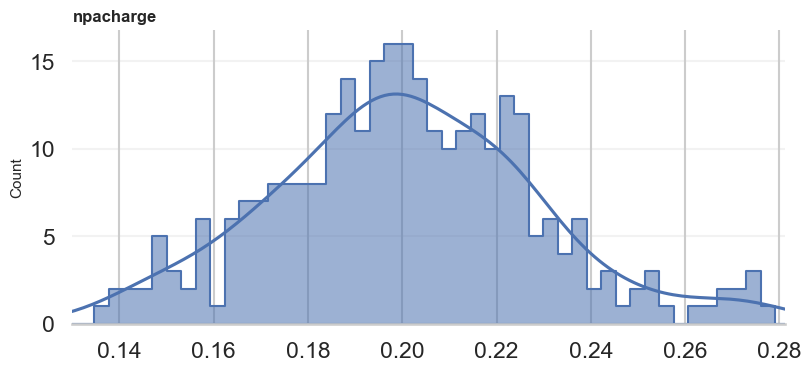

In [17]:
plot_distributions_seaborn(error_dict, keys=keys, bins=60, kde=True)